# IT25103997 — Senavirathna K. V. L. C. M.
## Individual Preprocessing Task: Feature Engineering — Feature Selection
**Dataset:** Chronic Kidney Disease (UCI ML Repository, id 336)
**Group:** 2026-Y2-S1-KU-56

This notebook demonstrates my individually assigned preprocessing technique — **feature selection** —
applied to the CKD dataset (building on `IT25103996_scaled.csv` from Gunasekara's notebook).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_style('whitegrid')
df = pd.read_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103997_feature_selected.csv')
X = df.drop(columns=['class'])
y = df['class']
print(X.shape, y.shape)

(399, 24) (399,)


### Why this technique is needed for this dataset
The CKD dataset has 24 candidate features. Not all of them contribute equally to predicting the target —
using every feature increases model complexity, training time, and the risk of overfitting given we only
have 399 records. Feature selection identifies the features that carry the most predictive signal so that
the models in Step 3 can be built more efficiently and interpretably.

In [ ]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
mi_series

hemo     0.452485
pcv      0.402263
sc       0.364440
rbcc     0.351382
sg       0.308380
al       0.229572
htn      0.222899
sod      0.218533
pot      0.202691
dm       0.196793
bu       0.174458
bgr      0.173571
appet    0.158100
bp       0.149987
wbcc     0.120448
pe       0.104245
pc       0.103617
su       0.087542
ba       0.073335
ane      0.067189
rbc      0.052609
age      0.046850
pcc      0.038524
cad      0.013431
dtype: float64

/tmp/ipykernel_255/2168715996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')


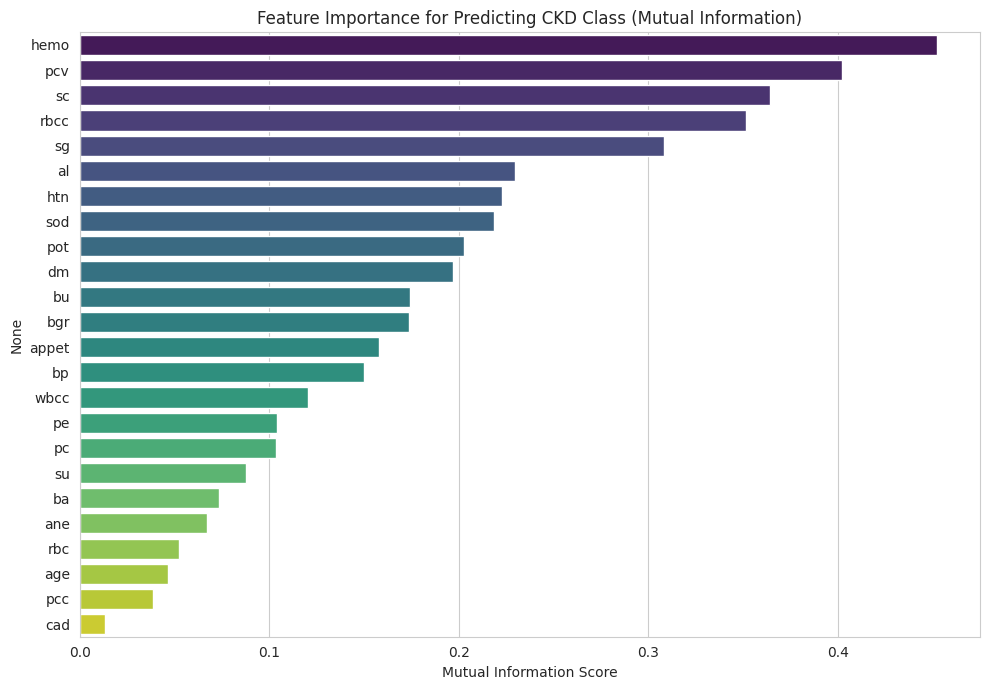

In [ ]:
# EDA Visualization 1: mutual information score per feature
plt.figure(figsize=(10,7))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance for Predicting CKD Class (Mutual Information)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103997_mutual_information_scores.png', dpi=120)
plt.show()

**Interpretation:** `sg` (specific gravity), `hemo` (hemoglobin), `pcv` (packed cell volume), `al`
(albumin) and `rbcc` (red blood cell count) carry by far the strongest signal — all clinically expected,
since impaired kidney function directly affects urine concentration (specific gravity), causes anemia
(lower hemoglobin/PCV/RBC count), and albumin in urine is a hallmark of kidney damage. Features like `ba`
(bacteria) and `cad` (coronary artery disease) contribute very little on their own.

In [ ]:
# Select the top-k most informative features (k=12, roughly half of the 24 candidates)
k = 12
selected_features = mi_series.head(k).index.tolist()
print("Selected features:", selected_features)

df_selected = df[selected_features + ['class']].copy()
df_selected.shape

Selected features: ['hemo', 'pcv', 'sc', 'rbcc', 'sg', 'al', 'htn', 'sod', 'pot', 'dm', 'bu', 'bgr']


(399, 13)

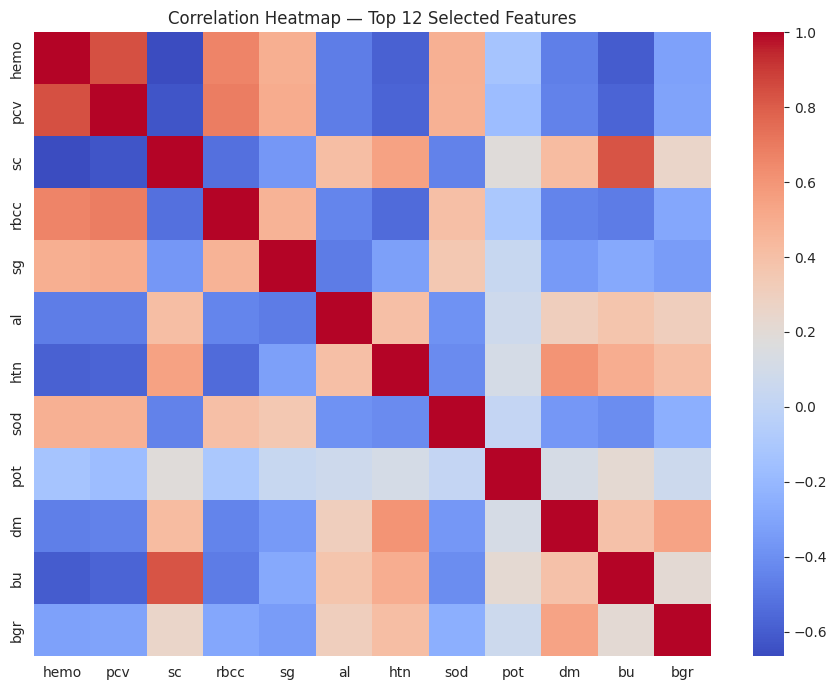

In [ ]:
# EDA Visualization 2: correlation heatmap restricted to the selected features
plt.figure(figsize=(9,7))
sns.heatmap(df_selected.drop(columns=['class']).corr(), annot=False, cmap='coolwarm')
plt.title(f'Correlation Heatmap — Top {k} Selected Features')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103997_selected_features_correlation.png', dpi=120)
plt.show()

**Interpretation:** A few of the selected features (e.g. `hemo`/`pcv`/`rbcc`) are themselves highly
correlated with each other, since they all measure aspects of the same underlying anemia signal. This is
useful context for the group's model-design step — tree-based models handle this redundancy well, while
linear models may benefit from further dimensionality reduction (handled next in Dissanayake's PCA
notebook).

In [ ]:
df_selected.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103997_feature_selected.csv', index=False)
print("Saved feature-selected dataset for downstream use by the group pipeline.")

Saved feature-selected dataset for downstream use by the group pipeline.


### Summary
- **Technique:** Feature selection using **Mutual Information** between each feature and the target class.
- **Justification:** With only 399 records and 24 candidate features, using every feature risks overfitting;
  mutual information ranks features by non-linear predictive relevance without assuming a linear relationship
  (unlike plain correlation), which suits a mix of numeric and encoded categorical clinical features.
- **Output:** `results/outputs/IT25103997_feature_selected.csv` — reduced to the top 12 most informative
  features plus the class label.